# Fold-aligned 3-seed bagging audit

서로 다른 CV split의 OOF를 평균하지 않습니다. outer fold를 42로 고정하고, 동일 fold-train에서 model seed 42/777/2024를 학습해 같은 validation 행의 확률만 평균합니다. train만 읽습니다.

In [1]:
from pathlib import Path
import subprocess, sys, json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
RUNNER = ROOT / 'experiments/gs/notebooks/exp_model_010/common/run_fold_aligned_h0_bagging_audit.py'
RESULT = ROOT / 'experiments/gs/notebooks/exp_model_010/result'
RUN_ID = 'exp-fold-aligned-h0-bagging-audit-01'
RUN_EXPERIMENT = True  # smoke 확인 뒤 True로 변경
assert RUNNER.exists()
print({'runner': RUNNER, 'result': RESULT, 'model_seeds': (42, 777, 2024), 'outer_split_seed': 42})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_010/common/run_fold_aligned_h0_bagging_audit.py'), 'result': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_010/result'), 'model_seeds': (42, 777, 2024), 'outer_split_seed': 42}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# train schema, NaN parser, fold 분리, test 미열람의 빠른 계약 검사
subprocess.run([sys.executable, str(RUNNER), '--smoke'], check=True)

{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "outer_split_seed": 42}


CompletedProcess(args=['/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/bin/python', '/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_010/common/run_fold_aligned_h0_bagging_audit.py', '--smoke'], returncode=0)

In [3]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='fold-aligned H0 bagging', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: smoke test와 기존 결과만 확인합니다.')

fold-aligned H0 bagging: 1line [00:04,  4.84s/line]

fold 1/5: fixed validation split, fitting 3 model seeds


fold-aligned H0 bagging: 2line [12:01, 423.64s/line]

fold 1/5 checkpoint saved
fold 2/5: fixed validation split, fitting 3 model seeds


fold-aligned H0 bagging: 4line [23:48, 379.59s/line]

...

fold-aligned H0 bagging: 10line [1:00:45, 375.07s/line]

fold 5/5 checkpoint saved


fold-aligned H0 bagging: 11line [1:00:46, 297.66s/line]

{"run_id": "exp-fold-aligned-h0-bagging-audit-01", "purpose": "fold_aligned_3seed_oof_bagging_audit", "outer_split_seed": 42, "model_seeds": [42, 777, 2024], "test_read": false, "train_test_concat": false, "all_models_exclude_each_validation_row": true, "invalid_cross_split_oof_average_used": false, "leakage_check": true, "nan_as_mutation_count": 0, "positive_fold_count_vs_seed42": 2, "decision": "audit_complete"}
            variant  outer_split_seed  model_seed_count  oof_macro_f1  oof_accuracy  feature_count_mean  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds  delta_vs_seed42_same_folds
            seed_42                42                 1      0.547915      0.558942              8219.2                          0           True                      0      3640.662838                    0.000000
           seed_777                42                 1      0.542721      0.557652              8219.2                          0           True         

fold-aligned H0 bagging: 16line [1:00:47, 227.94s/line]


In [5]:
summary = pd.read_csv(RESULT / f'{RUN_ID}_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
assert audit['all_models_exclude_each_validation_row'] and not audit['invalid_cross_split_oof_average_used']
display(summary)
fold_compare = (
    folds.query("variant in ['seed_42', 'fold_aligned_bagged']")
    .drop_duplicates(subset=["fold", "variant"], keep="last")
    .pivot(index="fold", columns="variant", values="macro_f1")
)

display(fold_compare)
audit

,variant,outer_split_seed,model_seed_count,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_seed42_same_folds
0,seed_42,42,1,0.547915,0.558942,8219.2,0,True,0,3640.662838,0.000000
1,seed_777,42,1,0.542721,0.557652,8219.2,0,True,0,3640.693751,-0.005194
2,seed_2024,42,1,0.543552,0.556201,8219.2,0,True,0,3640.715991,-0.004363
3,fold_aligned_bagged,42,3,0.546091,0.559426,8219.2,0,True,0,3640.739429,-0.001823


variant,fold_aligned_bagged,seed_42
fold,,
1,0.526070,0.528516
2,0.553789,0.551891
3,0.532046,0.543449
4,0.551372,0.554759
5,0.567139,0.558499


{'run_id': 'exp-fold-aligned-h0-bagging-audit-01',
 'purpose': 'fold_aligned_3seed_oof_bagging_audit',
 'outer_split_seed': 42,
 'model_seeds': [42, 777, 2024],
 'test_read': False,
 'train_test_concat': False,
 'all_models_exclude_each_validation_row': True,
 'invalid_cross_split_oof_average_used': False,
 'leakage_check': True,
 'nan_as_mutation_count': 0,
 'positive_fold_count_vs_seed42': 2,
 'decision': 'audit_complete'}

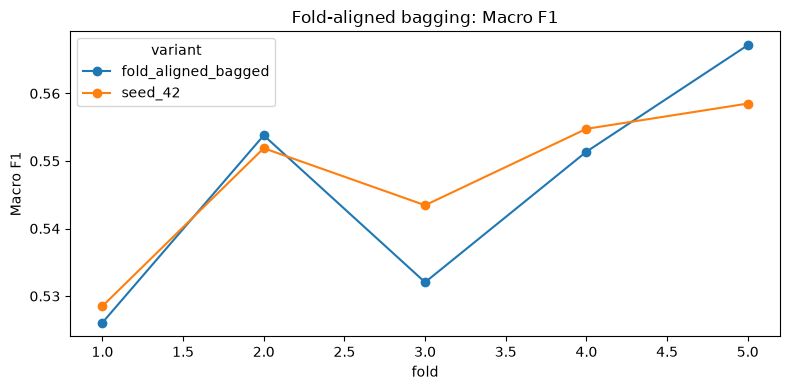

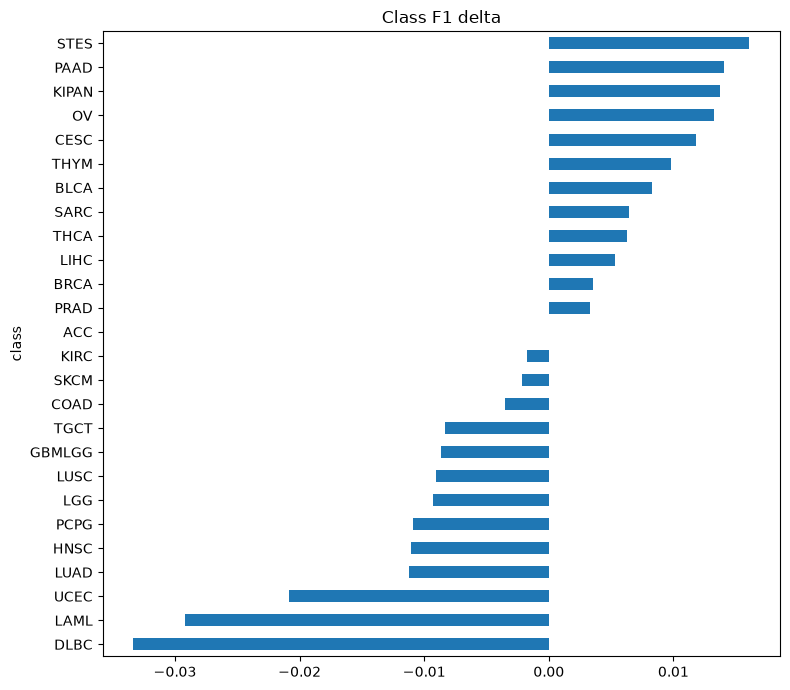

positive folds: 2 / 5


In [6]:
pivot = (
    folds.query("variant in ['seed_42', 'fold_aligned_bagged']")
    .drop_duplicates(subset=["fold", "variant"], keep="last")
    .pivot(index="fold", columns="variant", values="macro_f1")
)
pivot.plot(marker='o', figsize=(8,4), title='Fold-aligned bagging: Macro F1')
plt.ylabel('Macro F1'); plt.tight_layout(); plt.show()
class_pivot = classes.pivot(index='class', columns='variant', values='f1')
(class_pivot['fold_aligned_bagged'] - class_pivot['seed_42']).sort_values().plot.barh(figsize=(8,7), title='Class F1 delta')
plt.tight_layout(); plt.show()
print('positive folds:', int((pivot['fold_aligned_bagged'] > pivot['seed_42']).sum()), '/ 5')